# OLS

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

pd.set_option('display.precision', 3)
np.set_printoptions(precision=3)

from matplotlib import pyplot as plt
import plotly.express as px

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.outliers_influence import OLSInfluence

from sklearn.preprocessing import StandardScaler

In [2]:
def load_wb(filepath, col_name, year='2018'):
    df = pd.read_csv(filepath, skiprows=4)
    return df[['Country Code', year]].rename(columns={year: col_name})

# fertilityだけCountry Nameも残す
fertility = pd.read_csv('../data/fertility_rate.csv', skiprows=4)
fertility = fertility[['Country Name', 'Country Code', '2018']].rename(columns={'2018': 'fertility_rate'})

gdp = load_wb('../data/gdp_per_capita.csv', 'gdp_per_capita')
gini = load_wb('../data/gini.csv', 'gini')
female_lfp = load_wb('../data/female_lfp.csv', 'female_lfp')
female_edu = load_wb('../data/female_edu.csv', 'female_edu')
pop_density = load_wb('../data/population_density.csv', 'pop_density')
edu_exp = load_wb('../data/education_expenditure.csv', 'edu_expenditure')

In [3]:
# mergeはCountry Codeをキーに順番につなぐ
dfs = [gdp, gini, female_lfp, female_edu, pop_density, edu_exp]

all_df = fertility.copy()
for d in dfs:
    all_df = pd.merge(all_df, d, on='Country Code', how='left')

In [4]:
oecd_codes = ['AUS','AUT','BEL','CAN','CHL','COL','CRI','CZE','DNK','EST',
              'FIN','FRA','DEU','GRC','HUN','ISL','IRL','ISR','ITA','JPN',
              'KOR','LVA','LTU','LUX','MEX','NLD','NZL','NOR','POL','PRT',
              'SVK','SVN','ESP','SWE','CHE','TUR','GBR','USA']

# OECD加盟38カ国に絞る
oecd_df = all_df[all_df['Country Code'].isin(oecd_codes)].reset_index(drop=True)
# イスラエルを除外
no_isr_df = oecd_df[oecd_df['Country Code'] != 'ISR'].reset_index(drop=True)

In [5]:
# 欠損値を含む行を削除
oecd_df = oecd_df.dropna().reset_index(drop=True)
no_isr_df = no_isr_df.dropna().reset_index(drop=True)

In [6]:
cols = ['gdp_per_capita', 'gini', 'female_lfp', 'female_edu', 'pop_density', 'edu_expenditure']

# 標準化
scaler = StandardScaler()
oecd_df[cols] = scaler.fit_transform(oecd_df[cols])
no_isr_df[cols] = scaler.fit_transform(no_isr_df[cols])

## モデル学習

In [7]:
model = smf.ols(
    formula='fertility_rate ~ gdp_per_capita + gini + female_lfp + female_edu + pop_density + edu_expenditure', 
    data=oecd_df).fit()

print(f'Adj. R2: {model.rsquared_adj:.3f}')

Adj. R2: 0.055


In [8]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         fertility_rate   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     1.318
Date:                Mon, 01 Jun 2026   Prob (F-statistic):              0.283
Time:                        14:45:15   Log-Likelihood:                -5.7914
No. Observations:                  34   AIC:                             25.58
Df Residuals:                      27   BIC:                             36.27
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.6246      0.055     29.424      0.000       1.511       1.738
gdp_per_capita     -0.0578      0.067     -0.857      0.399      -0.196       0.080
gini                0.0943      0.068      1.391      0.176      -0.045       0.233
female_lfp          0.0371      0.073      0.507      0.616      -0.113       0.187
female_edu         -0.0387      0.065     -0.599      0.554      -0.171       0.094
pop_density         0.0301      0.059      0.513      0.612      -0.090       0.150
edu_expenditure     0.1104      0.065      1.697      0.101      -0.023       0.244
==============================================================================
Omnibus:                       26.322   Durbin-Watson:                   2.183
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               66.849
Skew:                           1.643   Prob(JB):                     3.05e-15
Kurtosis:                       9.032   Cond. No.                         2.36
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

イスラエルを除外すると人口密度・政府教育支出と出生率の間に一定の傾向が見られるが、サンプルサイズの制約から統計的有意性の判断には慎重を要する

## 回帰診断

回帰診断はイスラエル除外の根拠を統計的に確認するため、全34カ国（イスラエルあり）のモデルに対して実施した。

In [9]:
# 多重共線性
vif_df = pd.DataFrame({
    'Variable': cols,
    'VIF': [variance_inflation_factor(oecd_df[cols].values, i) 
            for i in range(len(cols))]
})
print(vif_df.sort_values('VIF', ascending=False))

          Variable    VIF
2       female_lfp  1.750
1             gini  1.509
0   gdp_per_capita  1.488
5  edu_expenditure  1.389
3       female_edu  1.366
4      pop_density  1.126


VIFの目安：
| VIF | 判断 |
|-----|-----|
| 1〜5 | 問題なし |
| 5〜10 | 注意 |
| 10以上 | 多重共線性あり|

* 全変数でVIF < 2と非常に低い
* 全変数のp値が有意でなかった原因は多重共線性ではないということが確認できたので、原因はサンプルサイズ（34カ国）の小ささとイスラエルなどの外れ値の影響である

### 残差分析

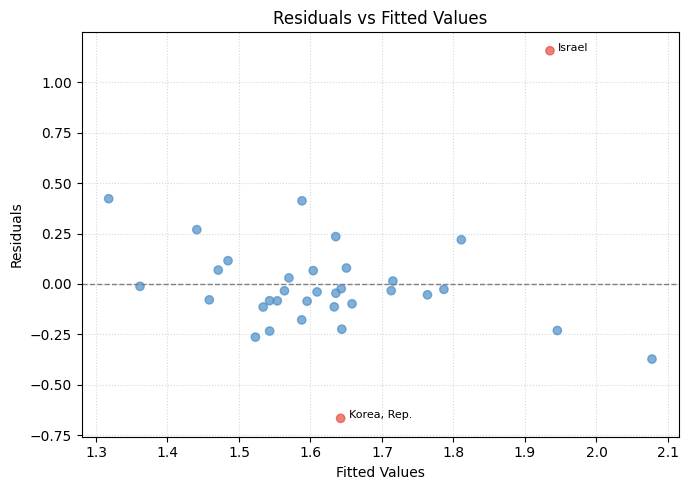

In [10]:
# ============================================================
# 残差プロット
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#E84C3D' if c == 'Israel' or c == 'Korea, Rep.' else '#4B8EC8' for c in oecd_df['Country Name']]

ax.scatter(model.fittedvalues, model.resid, color=colors, alpha=0.7)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# 残差が0.5以上の国名を表示
for i, row in oecd_df.iterrows():          # oecd_dfを1行ずつ取り出す（iはインデックス、rowは行データ）
    resid = model.resid[i]
    fitted = model.fittedvalues[i]
    if abs(resid) > 0.5:
        ax.annotate(row['Country Name'], 
                    xy=(fitted, resid),    # ラベルを付ける座標（予測値,残差）
                    xytext=(6, 0),         # ラベルを座標から右に6ポイントずらして表示
                    textcoords='offset points',
                    fontsize=8, color='black')

ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted Values')
ax.grid(linestyle=':', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../images/residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()

* 全体としては概ね等分散で大きな問題はないが、イスラエル・韓国が外れ値の可能性あり
* 2点の外れ値が正規性の仮定を歪めている

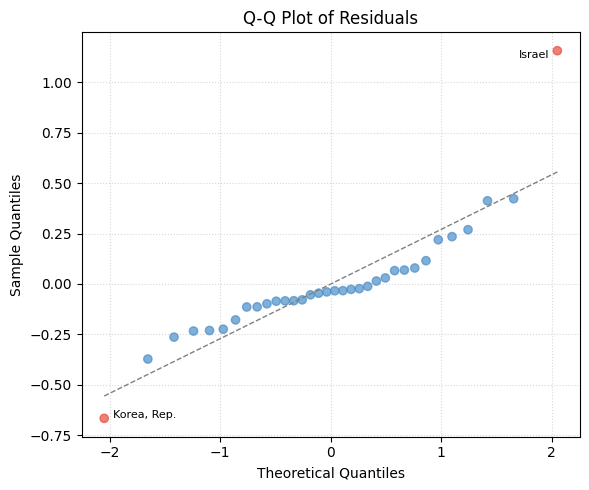

In [11]:
# ============================================================
# 正規Q-Qプロット
# ============================================================

resid = model.resid.values

# 理論分位数と標本分位数を取得
# osm: Ordered Score Mean（理論分位数）
# 「正規分布なら何番目の点はこの値のはず」という理論上の期待値
# → X軸の値
# osr: Ordered Sample Residuals（標本分位数）
# 実際の残差を小さい順にソートしたもの
# → Y軸の値
# slope: 参照線の傾き
# intercept: 参照線の切片
# _: 相関係数（今回は使わないので _ で受け取る）
(osm, osr), (slope, intercept, _) = stats.probplot(resid, dist='norm')

# 残差をソートして国名と対応させる
sort_idx = np.argsort(resid)
sorted_countries = oecd_df['Country Name'].values[sort_idx]

highlight = ['Israel', 'Korea, Rep.']
colors = ['#E84C3D' if c in highlight else '#4B8EC8' for c in sorted_countries]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(osm, osr, color=colors, alpha=0.7)

annotation_xy = {'Israel': (-28, -5), 'Korea, Rep.': (6, 0)}
for i, (country, x, y) in enumerate(zip(sorted_countries, osm, osr)):
    if country in highlight:
        ax.annotate(country,
                    xy=(x, y),
                    xytext=annotation_xy[country],
                    textcoords='offset points',
                    fontsize=8, color='black')

# 参照線
ax.plot([osm.min(), osm.max()],
        [slope * osm.min() + intercept, slope * osm.max() + intercept],
        color='gray', linestyle='--', linewidth=1)

ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.set_title('Q-Q Plot of Residuals')
ax.grid(linestyle=':', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('../images/q-q_plot.png', dpi=150, bbox_inches='tight')
plt.show()

* 韓国（左端）：参照線より下にある → 理論値より残差（実測値 - 予測値）が小さい（負方向の外れ値）
  → 予測値より実測値が小さい
* イスラエル（右端）：参照線より上にある → 理論値より残差（実測値 - 予測値）が大きい（正方向の外れ値）
  → 予測値より実測値が大きい

両端が線から外側に離れる形（左端が下、右端が上）は**裾が重い分布**（leptokurtic）を示しており、OLSサマリーのKurtosis（尖度）: 9.032と一致。

イスラエル（正方向）と韓国（負方向）の2つの外れ値が残差の正規性を歪めている。

韓国はOECD内で突出して低い出生率（0.977）を持ち、モデルが捉えきれない固有の要因（
超少子化・高学歴化・住宅コスト等）が存在する可能性を示唆している。
イスラエルは宗教・文化的背景による例外的な高出生率国であり、
いずれもOLS回帰の説明変数では捉えにくい構造的な特殊性を持つ。

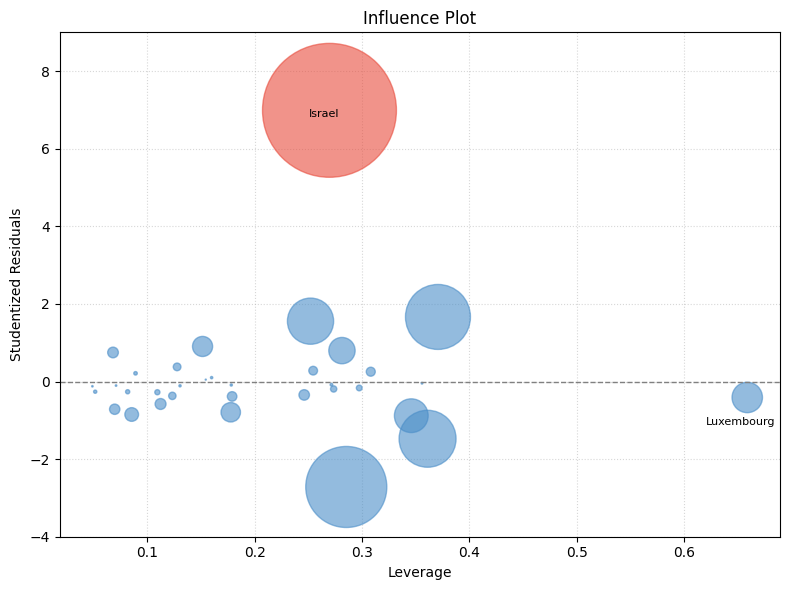

In [12]:
# ============================================================
# Influence Plot
# ============================================================

influence = OLSInfluence(model)
leverage         = influence.hat_matrix_diag
cooks_d          = influence.cooks_distance[0]
# Standardized残差: 残差 ÷ 残差全体の標準偏差
# Studentized残差: 残差 ÷ その観測値を除いたときの標準偏差
studentized_resid = influence.resid_studentized_external

colors = ['#E84C3D' if c == 'Israel' else '#4B8EC8' 
          for c in oecd_df['Country Name']]

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(leverage, studentized_resid, 
           s=cooks_d * 10000,  # バブルサイズ = Cookの距離
           color=colors, alpha=0.6)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Cookの距離が大きい点に国名を表示
annotation_xy = {'Israel': (-15, -5), 'Luxembourg': (-30, -20)}
for i, row in oecd_df.iterrows():
    if cooks_d[i] > 0.5 or leverage[i] > 0.4:   # Cookの距離が0.5を超えるとその観測値の影響力は大きく、外れ値とされる
        ax.annotate(row['Country Name'],
                    xy=(leverage[i], studentized_resid[i]),
                    xytext=annotation_xy[row['Country Name']],
                    textcoords='offset points',
                    fontsize=8, color='black')

ax.set_xlabel('Leverage')
ax.set_ylabel('Studentized Residuals')
ax.set_title('Influence Plot')
ax.grid(linestyle=':', alpha=0.5)
ax.set_axisbelow(True)
plt.ylim(-4, 9)
plt.tight_layout()
plt.savefig('../images/influence_plot.png', dpi=150, bbox_inches='tight')
plt.show()

* Cookの距離が外れ値の基準（0.5）を超えるのはイスラエルのみ（0.93）
  → モデル全体への影響力が大きい外れ値

* Leverageが高いのはルクセンブルクのみ（0.66）
  → 説明変数の空間で他国から離れた位置にある（極端に高いGDP per capita）
  → ただしCookの距離は小さいため、モデルへの実質的な影響は限定的

→ 統計的に有意な外れ値（モデルへの影響力が大きい）はイスラエルのみ

## モデル学習（イスラエルなし）

In [13]:
# イスラエルなし
model_no_isr = smf.ols(
    formula='fertility_rate ~ gdp_per_capita + gini + female_lfp + female_edu + pop_density + edu_expenditure', 
    data=no_isr_df).fit()

print(f'Adj. R2: {model_no_isr.rsquared_adj:.3f}')

Adj. R2: 0.149


In [14]:
model_no_isr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         fertility_rate   R-squared:                       0.309
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     1.934
Date:                Mon, 01 Jun 2026   Prob (F-statistic):              0.113
Time:                        14:46:53   Log-Likelihood:                 11.335
No. Observations:                  33   AIC:                            -8.670
Df Residuals:                      26   BIC:                             1.806
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.5802      0.034     46.948      0.000       1.511       1.649
gdp_per_capita     -0.0107      0.042     -0.257      0.799      -0.096       0.075
gini                0.0259      0.042      0.616      0.543      -0.061       0.112
female_lfp         -0.0424      0.045     -0.936      0.358      -0.136       0.051
female_edu         -0.0447      0.039     -1.143      0.263      -0.125       0.036
pop_density        -0.0745      0.037     -2.021      0.054      -0.150       0.001
edu_expenditure     0.0762      0.040      1.925      0.065      -0.005       0.158
==============================================================================
Omnibus:                        0.558   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.756   Jarque-Bera (JB):                0.634
Skew:                          -0.055   Prob(JB):                        0.728
Kurtosis:                       2.330   Cond. No.                         2.43
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

* 人口密度・政府教育支出がp≒0.05〜0.06で傾向あり

p=0.054（人口密度）・p=0.065（政府教育支出）は
5%水準では非有意だが10%水準では有意であり、
サンプルサイズ（33カ国）の制約を踏まえると一定の傾向として解釈できる

* イスラエルという外れ値がモデルを歪めていたことが確認される

イスラエル除外前：調整済みR²=0.055、F統計量p=0.283（モデル全体が非有意）
イスラエル除外後：調整済みR²=0.149、F統計量p=0.113（改善）
→ イスラエルの除外によりモデルの説明力が改善された

* 人口密度が1標準偏差（142）増加するごとに出生率が0.08ポイント減少する
* 政府教育支出が1標準偏差（1.25）増加するごとに出生率が0.08ポイント増加する

政府教育支出の1標準偏差は約1.25%pt（対GDP比）に相当し、
1標準偏差の増加ごとに出生率が約0.08ポイント増加する傾向がある
（ただしp=0.065で統計的有意性は限定的）

600兆円(日本の2024年の名目GDP総額) × 1.25% = 7.5兆円

ただしこれは日本単独への適用ではなく、OECD33カ国の平均的な関係から導いた数値なので、「日本が教育支出を7.5兆円増やせば出生率が0.08上がる」とは言えない。あくまで「OECD諸国を横断的に見ると、教育支出が多い国ほど出生率がわずかに高い傾向がある」という解釈に留まる。

政府の教育支出と出生率の間に正の傾向が示唆されたが、
統計的有意性は限定的（p=0.065）であり、
因果関係の特定には都道府県レベルのパネルデータを用いた
より精緻な分析が必要である（4本目へ続く）

## 考察

* 単純なOLSでは格差指標の有意な効果は確認できなかった
* より大きなサンプルと精緻な手法（因果推論）での検証が必要